# The Product Pricer Continued

A model that can estimate how much something costs, from its description.

## Data Curation Part 2

Today we'll extend our dataset to a greater coverage, and craft it into an excellent dataset for training.

The dataset is here:  
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023

And the folder with all the product datasets is here:  
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/tree/main/raw/meta_categories

## The Lite1 dataset with Performance Tune - within 30 mins (exclude the download time to *.jsonl).

This notebook is an alternative to `day2.ipynb` that creates a smaller dataset for Home Appliances only, to keep training fast and costs low. You may need to update names of future notebooks to reflect that you have built the "lite" dataset not the full dataset.

In [1]:
# imports

import os
import random
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset, Dataset, DatasetDict
from items import Item
from loaders import ItemLoader
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import numpy as np
import pickle

# Concurrent load dataset with 4 simultaneously 
from concurrent.futures import ThreadPoolExecutor, as_completed

In [2]:
# environment

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

In [3]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [4]:
%matplotlib inline

## The ItemLoader code

Look in loaders.py - there's some useful code to make life easier for us

## Now to SCALE UP

Let's look at all datasets of all the items that you might find in a large home retail store - electrical, electronic, office and related, but not clothes / beauty / books.

In [5]:
dataset_names = [
    "Automotive",    
    "Office_Products",
    "Toys_and_Games", 
    "Tools_and_Home_Improvement",     
    "Software",
    "Electronics",    
    "Health_and_Personal_Care",
    "Cell_Phones_and_Accessories",    
    "Appliances",
    "Musical_Instruments",
]

In [6]:
# Enhanced version to keep the datasets and chucks into disk
# items = []
# for dataset_name in dataset_names:
#     loader = ItemLoader(dataset_name)
#     items.extend(loader.load(6))

# Further performance fine tune ...
# import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

MAX_WORKERS = 6  # Load 6 datasets at a time

def load_dataset_items(name: str):
    try:
        loader = ItemLoader(name, show_progress=False)
        return loader.load(workers=1) # 避免 ThreadPoolExecutor 和 multiprocessing 混用時常見的錯誤
    except Exception as e:
        print(f"❌ Error loading {name}: {e}")
        return []

items = []

# ✅ Run safely with error handling
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(load_dataset_items, name): name for name in dataset_names}
    for future in as_completed(futures):
        try:
            dataset_items = future.result()
            items.extend(dataset_items)
        except Exception as e:
            print(f"⚠️ Unhandled exception: {e}")

print(f"\n✅ Total items loaded: {len(items):,}")


🔍 Loading dataset: Automotive
🔍 Loading dataset: Office_Products
🔍 Loading dataset: Toys_and_Games
⬇️ Downloading from Hugging Face Hub...
⬇️ Downloading from Hugging Face Hub...
🔍 Loading dataset: Tools_and_Home_Improvement
🔍 Loading dataset: Software
⬇️ Downloading from Hugging Face Hub...
⬇️ Downloading from Hugging Face Hub...
⬇️ Downloading from Hugging Face Hub...
🔍 Loading dataset: Electronics
⬇️ Downloading from Hugging Face Hub...


README.md:   0%|          | 0.00/30.3k [00:00<?, ?B/s]

Amazon-Reviews-2023.py:   0%|          | 0.00/39.6k [00:00<?, ?B/s]

meta_Software.jsonl:   0%|          | 0.00/256M [00:00<?, ?B/s]

meta_Toys_and_Games.jsonl:   0%|          | 0.00/2.64G [00:00<?, ?B/s]

...

✅ Completed Musical_Instruments with 66,829 datapoints in 10.5 mins
💾 Caching to: cache\Electronics_dataset


Saving the dataset (0/10 shards):   0%|          | 0/1610012 [00:00<?, ? examples/s]

💾 Caching to: cache\Automotive_dataset


Saving the dataset (0/10 shards):   0%|          | 0/2003129 [00:00<?, ? examples/s]

✅ Completed Cell_Phones_and_Accessories with 238,869 datapoints in 45.9 mins
✅ Completed Electronics with 443,473 datapoints in 55.1 mins
✅ Completed Tools_and_Home_Improvement with 541,051 datapoints in 56.2 mins
✅ Completed Automotive with 911,688 datapoints in 65.9 mins

✅ Total items loaded: 2,830,634


In [7]:
print(f"A grand total of {len(items):,} items")

A grand total of 2,830,634 items


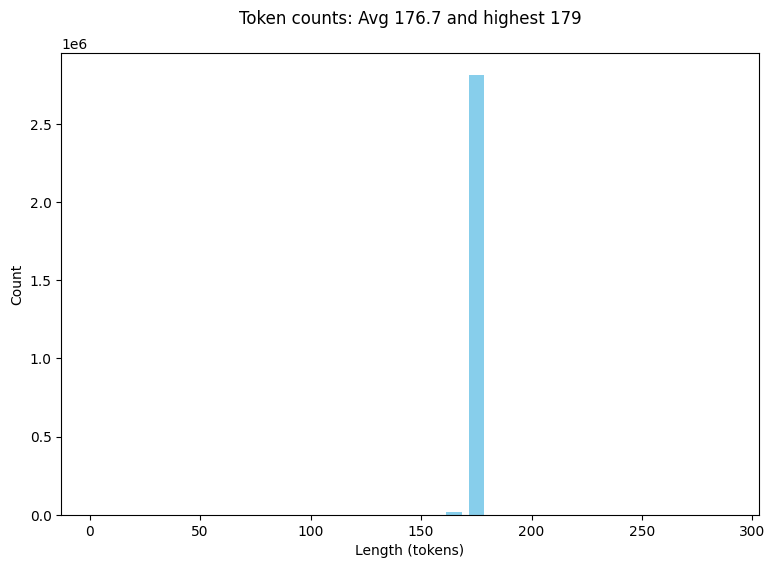

In [8]:
# Plot the distribution of token counts again

tokens = [item.token_count for item in items]
plt.figure(figsize=(9, 6))
plt.title(f"Token counts: Avg {sum(tokens)/len(tokens):,.1f} and highest {max(tokens):,}\n")
plt.xlabel('Length (tokens)')
plt.ylabel('Count')
plt.hist(tokens, rwidth=0.7, color="skyblue", bins=range(0, 300, 10))
plt.show()

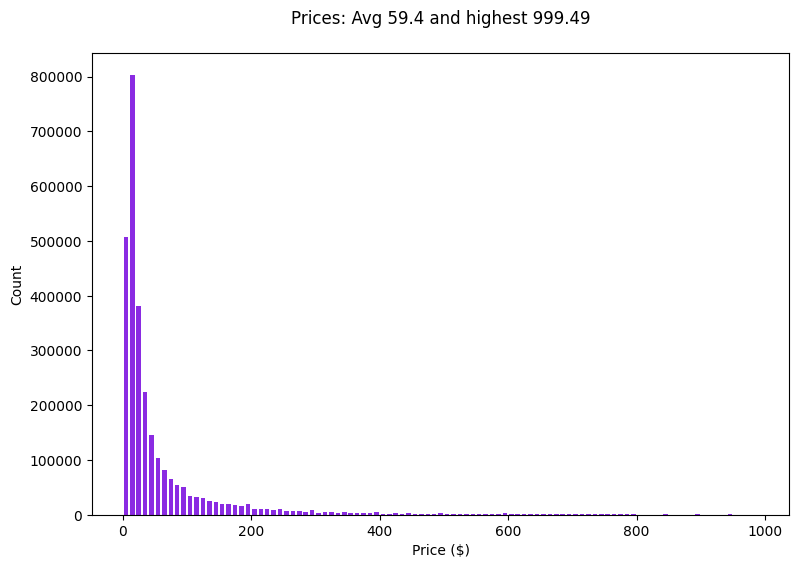

In [9]:
# Plot the distribution of prices

prices = [item.price for item in items]
plt.figure(figsize=(9, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

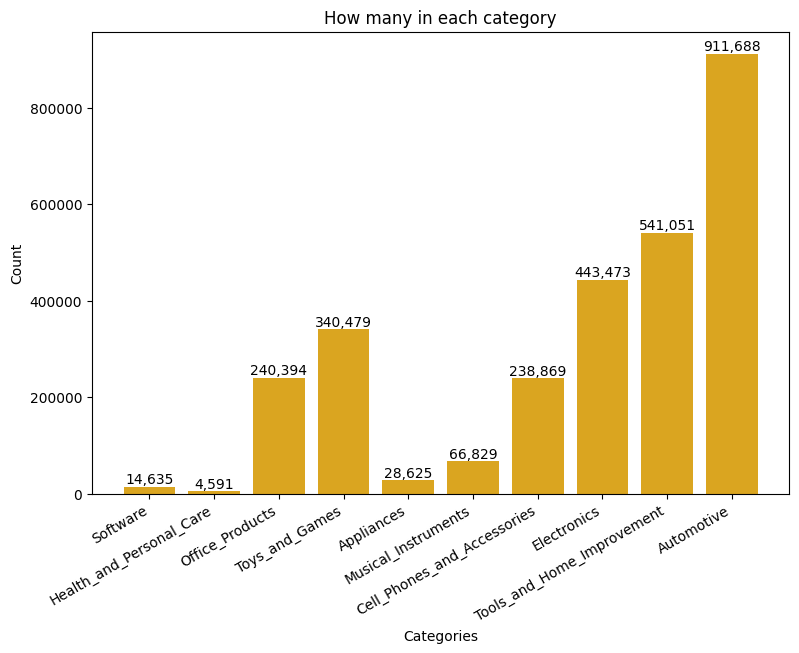

In [10]:
category_counts = Counter()
for item in items:
    category_counts[item.category]+=1

categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

# Bar chart by category
plt.figure(figsize=(9, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')

plt.xticks(rotation=30, ha='right')

# Add value labels on top of each bar
for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

# Display the chart
plt.show()

# Objective

Craft a dataset which is more balanced in terms of prices. Less heavily scewed to cheap items, with an average that's higher than $60. Try to balance out the categories - fewer Automotive items.

In [11]:
# Create a dict with a key of each price from $1 to $999
# And in the value, put a list of items with that price (to nearest round number)

slots = defaultdict(list)
for item in items:
    slots[round(item.price)].append(item)

In [12]:
# Create a dataset called "sample" which tries to more evenly take from the range of prices
# And gives more weight to items from categories other than Automotive
# Set random seed for reproducibility

np.random.seed(42)
random.seed(42)
sample = []
for i in range(1, 1000):
    slot = slots[i]
    if i>=240:
        sample.extend(slot)
    elif len(slot) <= 1200:
        sample.extend(slot)
    else:

        category_weights = {
            'Automotive': 1
            # 'Musical_Instruments': 6.5,
            # 'Office_Products': 6.25,
            # 'Cell_Phones_and_Accessories': 3.5
        }
        
        weights = np.array([category_weights.get(item.category, 5) for item in slot])        
        # weights = np.array([1 if item.category in ('Musical_Instruments', 'Office_Products') else 6 for item in slot])
        weights = weights / np.sum(weights)
        selected_indices = np.random.choice(len(slot), size=1200, replace=False, p=weights)
        selected = [slot[i] for i in selected_indices]
        sample.extend(selected)

print(f"There are {len(sample):,} items in the sample")

There are 408,814 items in the sample


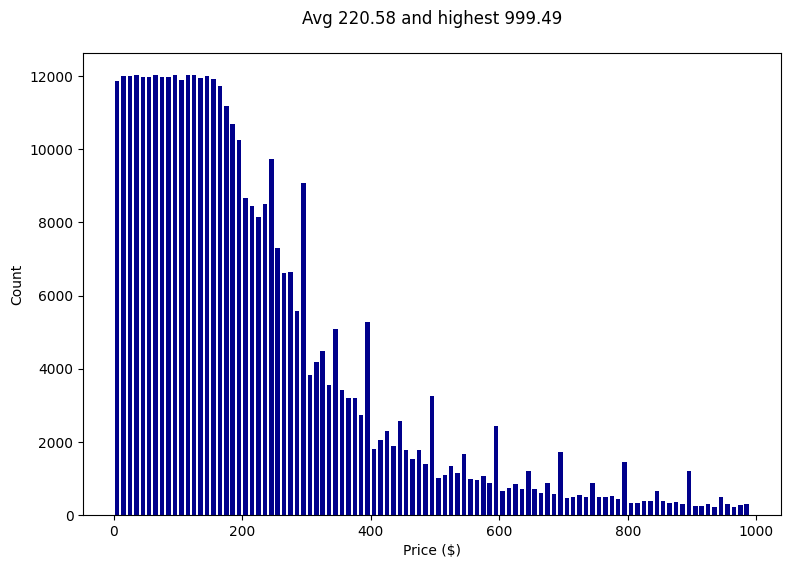

In [13]:
# Plot the distribution of prices in sample

prices = [float(item.price) for item in sample]
plt.figure(figsize=(9, 6))
plt.title(f"Avg {sum(prices)/len(prices):.2f} and highest {max(prices):,.2f}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="darkblue", bins=range(0, 1000, 10))
plt.show()

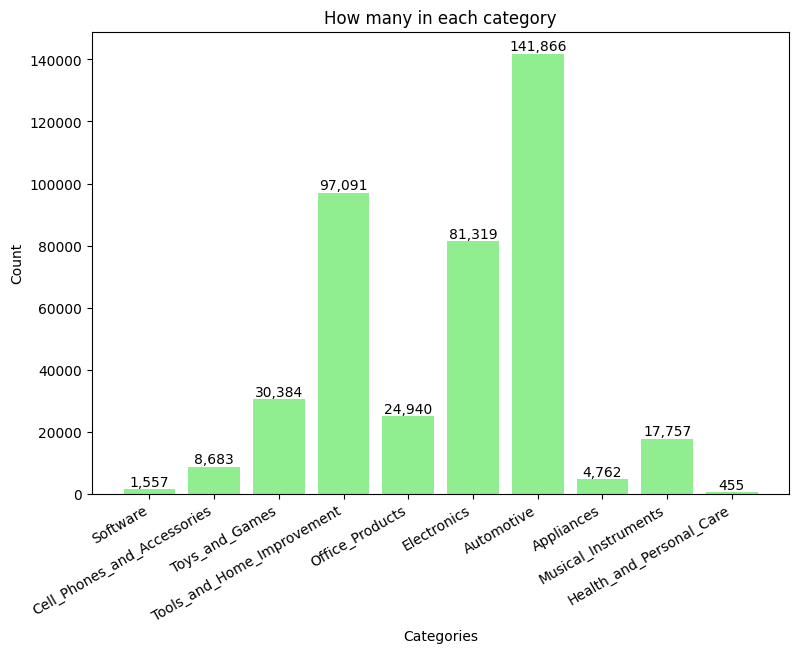

In [14]:
# OK, we did well in terms of raising the average price and having a smooth-ish population of prices
# Let's see the categories

category_counts = Counter()
for item in sample:
    category_counts[item.category]+=1

categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

# Create bar chart
plt.figure(figsize=(9, 6))
plt.bar(categories, counts, color="lightgreen")

# Customize the chart
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')

plt.xticks(rotation=30, ha='right')

# Add value labels on top of each bar
for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

# Display the chart
plt.show()

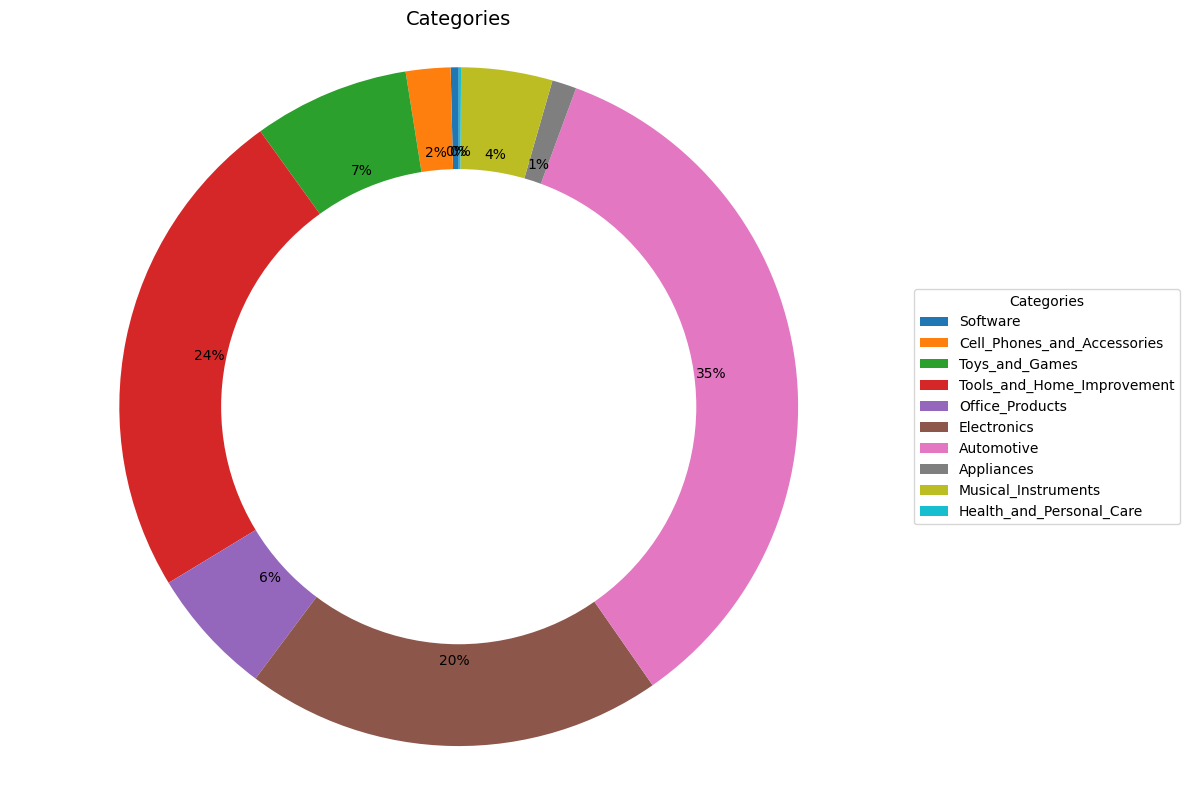

In [15]:
# Automotive still in the lead, but improved somewhat
# For another perspective, let's look at a pie

plt.figure(figsize=(12, 8))

# Draw pie chart with minimal inline labels
wedges, texts, autotexts = plt.pie(
    counts,
    autopct='%1.0f%%',
    startangle=90,
    pctdistance=0.75,
    textprops={'fontsize': 10}
)

# Add a circle to make it a donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Add title
plt.title('Categories', fontsize=14)

# Add legend to the right
plt.legend(wedges, categories, title="Categories", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

# Ensure pie is circular and layout fits
plt.axis('equal')
plt.tight_layout()
plt.show()


# Dataset Curated!

We've crafted an excellent dataset.

Let's do some final checks

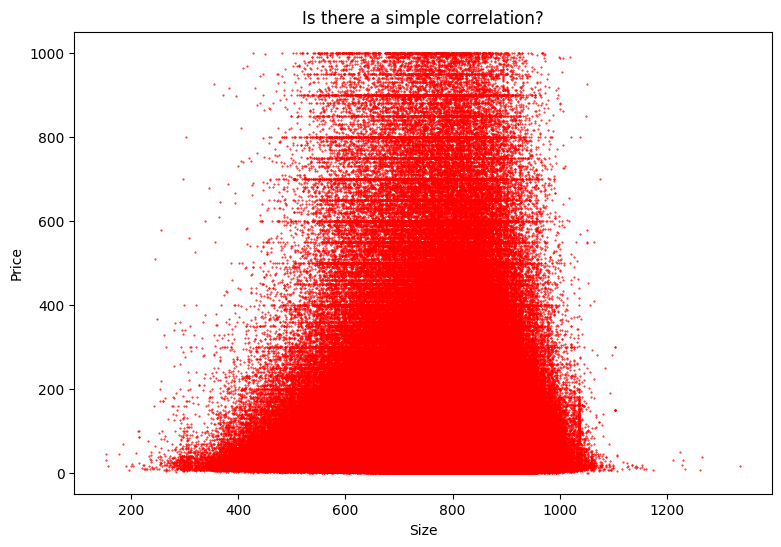

In [16]:
# How does the price vary with the character count of the prompt?

sample = items

sizes = [len(item.prompt) for item in sample]
prices = [item.price for item in sample]

# Create the scatter plot
plt.figure(figsize=(9, 6))
plt.scatter(sizes, prices, s=0.2, color="red")

# Add labels and title
plt.xlabel('Size')
plt.ylabel('Price')
plt.title('Is there a simple correlation?')

# Display the plot
plt.show()

In [17]:
def report(item):
    prompt = item.prompt
    tokens = Item.tokenizer.encode(item.prompt)
    print(f"Prompt: \n{prompt}")

    last_tokens = tokens[-10:]
    print(f"\nLast 10 tokens: {last_tokens}")
    print(f"Item tokenizer decode last 10 tokens: {Item.tokenizer.batch_decode(last_tokens)}")

In [18]:
report(sample[2000])

Prompt: 
How much does this cost to the nearest dollar?

Village Farmer Simulator 3D
Envy the life of Village Farmer or just want to try harvesting? Now you can be your very own yeoman! The crops are your children--take care of them! You’ll get to drive all the different farm vehicles Plough the seeds in careful order so they are ready later to be harvested. When the season comes, reap your fruit with a harvester! Complete several tasks like this efficiently. Make sure not to miss any, as food is money!About TapinatorTapinator (Ticker TAPM) designs, develops, and publishes games on mobile platforms. The Company’s portfolio includes over 200 mobile gaming titles that, collectively, have achieved over 200 million downloads. Tapinator is headquartered in New York. For more info, visit Tap

Price is $1.00

Last 10 tokens: [11, 4034, 37234, 271, 7117, 374, 400, 16, 13, 410]
Item tokenizer decode last 10 tokens: [',', ' visit', ' Tap', '\n\n', 'Price', ' is', ' $', '1', '.', '00']


In [19]:
report(sample[500000])

Prompt: 
How much does this cost to the nearest dollar?

Swimline Giant Inflatable 62 Baseball Glove Swimming Pool Float (2 Pack)
The Swimline Inflatable Baseball Glove Float is a real catch at the pool, lake, or beach this summer. For the ultimate baseball lover, this float hits it out of the park and is great for sunning and relaxing. It features a realistic baseball glove design with leather stitch graphics and lettering and is constructed from heavy-duty vinyl. The float has room for 1 adult or 2 younger kiddos to get caught in, and lasts season after season. The inflated glove-grooves have super comfy cushioning so you can rest your head wherever you want. You can even flip over on your tummy for a thorough tan. Steal the hearts of your baseball-loving fans and strike

Price is $50.00

Last 10 tokens: [7359, 323, 13471, 271, 7117, 374, 400, 1135, 13, 410]
Item tokenizer decode last 10 tokens: [' fans', ' and', ' strike', '\n\n', 'Price', ' is', ' $', '50', '.', '00']


## Observation

An interesting thing about the Llama tokenizer is that every number from 1 to 999 gets mapped to 1 token, much as we saw with gpt-4o. The same is not true of qwen2, gemma and phi3, which all map individual digits to tokens. This does turn out to be a bit useful for our project, although it's not an essential requirement.

# Finally

It's time to break down our data into a training, test and validation dataset.

It's typical to use 5%-10% of your data for testing purposes, but actually we have far more than we need at this point. We'll take 25,000 points for training, and we'll reserve 2,000 for testing, although we won't use all of them.


In [20]:
## Ramdon Sample => takes first 100_000 for training and next 3_000 for testing

random.seed(42)
random.shuffle(sample)
train = sample[:100_000]
test = sample[100_000:103_000]
print(f"Divided into a training set of {len(train):,} items and test set of {len(test):,} items")

Divided into a training set of 100,000 items and test set of 3,000 items


In [21]:
print(train[0].prompt)

How much does this cost to the nearest dollar?

E-repair Complete Full Set Screws Replacement for iPhone 7
1x Full screw set for iPhone 7 1x Clean Wiper Come with bottom screws 2x gold, 2x silver, 2x black. Including Clean Wiper with E-REPAIR LOGO Compatible with iPhone 7 It is full set screws to assemble a complete phone. Including bottom Pentalobe Screws black, silver and gold colors Dimensions 2.99 x 2.01 x 0.2 inches, Weight 1.58 ounces, model number Rank Cell Phones & Accessories 57932, Cell Phone Replacement Parts 1301, Is Discontinued No, Other display features Wireless, Manufacturer E-REPAIR, Available December 4, 2016

Price is $6.00


In [22]:
print(test[0].test_prompt())

How much does this cost to the nearest dollar?

Outlaw Racing OR3785 Complete Full Engine Gasket Set Compatible with Yamaha YZ250 Dirt Kit
Outlaw Racing Complete Gasket Kits are exactly what you need to get your bike rebuilt and running right! Using materials such as Stainless Steel, Fluoroviton and Teflon, our gaskets are made to exact OEM specs but with better materials to last longer and keep your bike running stronger. Each kit will contain the exact gaskets, seals and o-rings you need to re-assemble your top and bottom engine components after a standard rebuild (no overbore sizes are available), and require no trimming or modification. ✅ Exactly what you need to get your bike rebuilt and running right! ✅ Each kit will contain the exact gaskets, seals, and o-rings you

Price is $


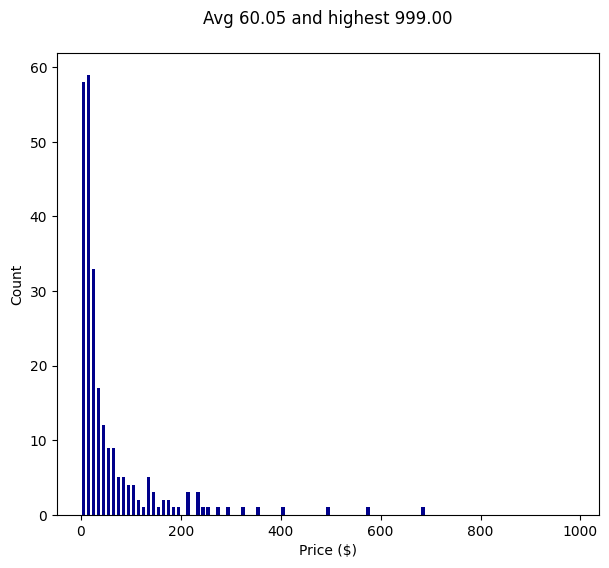

In [23]:
# Plot the distribution of prices in the first 250 test points

prices = [float(item.price) for item in test[:250]]
plt.figure(figsize=(7, 6))
plt.title(f"Avg {sum(prices)/len(prices):.2f} and highest {max(prices):,.2f}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="darkblue", bins=range(0, 1000, 10))
plt.show()

# Finally - upload your brand new dataset

Convert to prompts and upload to HuggingFace hub

In [24]:
train_prompts = [item.prompt for item in train]
train_prices = [item.price for item in train]
test_prompts = [item.test_prompt() for item in test]
test_prices = [item.price for item in test]

In [25]:
# Create a Dataset from the lists

train_dataset = Dataset.from_dict({"text": train_prompts, "price": train_prices})
test_dataset = Dataset.from_dict({"text": test_prompts, "price": test_prices})
dataset = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

In [26]:
DATASET_NAME = "christseng898/lite-data"
dataset.push_to_hub(DATASET_NAME, private=True)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/100 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

README.md:   0%|          | 0.00/413 [00:00<?, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/datasets/christseng898/lite-data/commit/dcc4bcd4facb1b6bef3df2d6ee2bea42cac111ab', commit_message='Upload dataset', commit_description='', oid='dcc4bcd4facb1b6bef3df2d6ee2bea42cac111ab', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/christseng898/lite-data', endpoint='https://huggingface.co', repo_type='dataset', repo_id='christseng898/lite-data'), pr_revision=None, pr_num=None)

In [27]:
# One more thing!
# Let's pickle the training and test dataset so we don't have to execute all this code next time!

with open('train_lite.pkl', 'wb') as file:
    pickle.dump(train, file)

with open('test_lite.pkl', 'wb') as file:
    pickle.dump(test, file)

## Todos for you:

- Investigate the dataset more!
- Confirm that the tokenizer tokenizes all 3 digit prices into 1 token

In [28]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

sample_prices = ["100", "249", "999"]
tokenized_prices = {price: tokenizer.tokenize(price) for price in sample_prices}
print(tokenized_prices)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

{'100': ['100'], '249': ['249'], '999': ['999']}


### Investigate the dataset more!

In [29]:
from datasets import load_dataset, get_dataset_config_names
configs = get_dataset_config_names("McAuley-Lab/Amazon-Reviews-2023")
print(configs)

['raw_meta_All_Beauty', 'raw_meta_Toys_and_Games', 'raw_meta_Cell_Phones_and_Accessories', 'raw_meta_Industrial_and_Scientific', 'raw_meta_Gift_Cards', 'raw_meta_Musical_Instruments', 'raw_meta_Electronics', 'raw_meta_Handmade_Products', 'raw_meta_Arts_Crafts_and_Sewing', 'raw_meta_Baby_Products', 'raw_meta_Health_and_Household', 'raw_meta_Office_Products', 'raw_meta_Digital_Music', 'raw_meta_Grocery_and_Gourmet_Food', 'raw_meta_Sports_and_Outdoors', 'raw_meta_Home_and_Kitchen', 'raw_meta_Subscription_Boxes', 'raw_meta_Tools_and_Home_Improvement', 'raw_meta_Pet_Supplies', 'raw_meta_Video_Games', 'raw_meta_Kindle_Store', 'raw_meta_Clothing_Shoes_and_Jewelry', 'raw_meta_Patio_Lawn_and_Garden', 'raw_meta_Unknown', 'raw_meta_Books', 'raw_meta_Automotive', 'raw_meta_CDs_and_Vinyl', 'raw_meta_Beauty_and_Personal_Care', 'raw_meta_Amazon_Fashion', 'raw_meta_Magazine_Subscriptions', 'raw_meta_Software', 'raw_meta_Health_and_Personal_Care', 'raw_meta_Appliances', 'raw_meta_Movies_and_TV', 'raw_r

In [30]:
dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", name="5core_timestamp_w_his_Musical_Instruments", split="train")


Musical_Instruments.train.csv:   0%|          | 0.00/53.9M [00:00<?, ?B/s]

Musical_Instruments.valid.csv:   0%|          | 0.00/6.98M [00:00<?, ?B/s]

Musical_Instruments.test.csv:   0%|          | 0.00/7.96M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating valid split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [31]:
print(dataset[0])
print(dataset.features)
print(f"Number of Musical Instruments: {len(dataset):,}")

{'user_id': 'AHV6QCNBJNSGLATP56JAWJ3C4G2A', 'parent_asin': 'B00OG187HC', 'rating': '5.0', 'timestamp': '1415286067000', 'history': ''}
{'user_id': Value(dtype='string', id=None), 'parent_asin': Value(dtype='string', id=None), 'rating': Value(dtype='string', id=None), 'timestamp': Value(dtype='string', id=None), 'history': Value(dtype='string', id=None)}
Number of Musical Instruments: 427,957


In [32]:
dataset1 = load_dataset("McAuley-Lab/Amazon-Reviews-2023", name="raw_meta_Handmade_Products", split="full", trust_remote_code=True)

meta_Handmade_Products.jsonl:   0%|          | 0.00/399M [00:00<?, ?B/s]

Generating full split:   0%|          | 0/164817 [00:00<?, ? examples/s]

In [33]:
print(dataset1[0])
print(dataset1.features)
print(f"Number of Handmade Product: {len(dataset1):,}")

{'main_category': 'Handmade', 'title': 'Daisy Keychain Wristlet Gray Fabric Key fob Lanyard', 'average_rating': 4.5, 'rating_number': 12, 'features': ['High Quality Fabrics', 'Antique Brass Metallic Hardware', '1" wide; Approx. 5-1/2" loop opening', 'Handmade in California'], 'description': ['This charming Daisy Fabric Keychain wristlet features an opening that loops around your wrist allowing your hands to be free to carry other things! This sweet floral daisy key fob will be your little dose of joy, lifting your spirits each time you reach for your keys! PRODUCT DETAILS: Approx. 7" long including the split ring to hold keys. Machine stitched over quality cotton fabric and firm interfacing on inside for structure yet comfortable to hold.'], 'price': 'None', 'images': {'hi_res': [None, None, 'https://m.media-amazon.com/images/I/51TpGYCdKIL._SL1000_.jpg', 'https://m.media-amazon.com/images/I/515dUKmwsbL._SL1000_.jpg', 'https://m.media-amazon.com/images/I/513oIHPmgUL._SL1000_.jpg'], 'lar